In [1]:
!pip install keras --upgrade tensorflow --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
ERROR: pip's dependency resolver does not currently ta

In [11]:
import matplotlib.pyplot as plt
from keras.datasets import imdb
from keras.utils import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding,SimpleRNN,LSTM,Dense,Bidirectional,Dropout


In [13]:
max_features = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

In [15]:
maxlen = 200
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

In [16]:
def train_model(model):
    model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
    history = model.fit(x_train,y_train,epochs=5,batch_size=128,validation_split=0.2,verbose=1)

    test_loss, test_acc = model.evaluate(x_test,y_test,verbose=0)

    return history, test_acc

In [17]:
model_rnn = Sequential([
    Embedding(max_features, 128),
    SimpleRNN(64),
    Dense(1, activation="sigmoid")
])

model_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_rnn, acc_rnn = train_model(model_rnn)
print("Звичайна рнн точність:", acc_rnn)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.9948 - loss: 0.0175 - val_accuracy: 0.7696 - val_loss: 0.8667
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9903 - loss: 0.0284 - val_accuracy: 0.7778 - val_loss: 0.8451
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9998 - loss: 0.0020 - val_accuracy: 0.8032 - val_loss: 0.8214
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 1.0000 - loss: 4.7679e-04 - val_accuracy: 0.7960 - val_loss: 0.8716
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 1.0000 - loss: 2.6007e-04 - val_accuracy: 0.7960 - val_loss: 0.8967
Звичайна рнн точність: 0.7966799736022949


In [20]:
model_lstm = Sequential([
    Embedding(max_features, 128),
    LSTM(64),
    Dense(1, activation="sigmoid")
])

model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_lstm, acc_lstm = train_model(model_lstm)

print("LSTM точність:", acc_lstm)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7792 - loss: 0.4482 - val_accuracy: 0.8550 - val_loss: 0.3415
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8999 - loss: 0.2562 - val_accuracy: 0.8552 - val_loss: 0.3317
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9338 - loss: 0.1790 - val_accuracy: 0.8696 - val_loss: 0.3198
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9564 - loss: 0.1275 - val_accuracy: 0.8686 - val_loss: 0.3611
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9618 - loss: 0.1118 - val_accuracy: 0.8632 - val_loss: 0.3776
LSTM точність: 0.8565999865531921


In [22]:
model_bilstm = Sequential([
    Embedding(max_features, 128),
    Bidirectional(LSTM(64)),
    Dense(1, activation="sigmoid")
])

model_bilstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
history_bilstm, acc_bilstm = train_model(model_bilstm)

print("BLSTM точність:", acc_bilstm)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.7733 - loss: 0.4553 - val_accuracy: 0.8618 - val_loss: 0.3271
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.8997 - loss: 0.2551 - val_accuracy: 0.8678 - val_loss: 0.3297
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9304 - loss: 0.1898 - val_accuracy: 0.8626 - val_loss: 0.3531
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9509 - loss: 0.1380 - val_accuracy: 0.8634 - val_loss: 0.3563
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9518 - loss: 0.1339 - val_accuracy: 0.8644 - val_loss: 0.4047
BLSTM точність: 0.8564800024032593


In [24]:
model_deep = Sequential([
    Embedding(max_features, 128),
    LSTM(64,return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dense(1, activation="sigmoid")
])

model_deep.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
history_deep, acc_deep = train_model(model_deep)

print("Deep LSTM точність:", acc_deep)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.7578 - loss: 0.4971 - val_accuracy: 0.8340 - val_loss: 0.3813
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8737 - loss: 0.3066 - val_accuracy: 0.8626 - val_loss: 0.3214
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9244 - loss: 0.2014 - val_accuracy: 0.8530 - val_loss: 0.3385
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9452 - loss: 0.1544 - val_accuracy: 0.8644 - val_loss: 0.3581
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9573 - loss: 0.1206 - val_accuracy: 0.8608 - val_loss: 0.4513
Deep LSTM точність: 0.8482800126075745


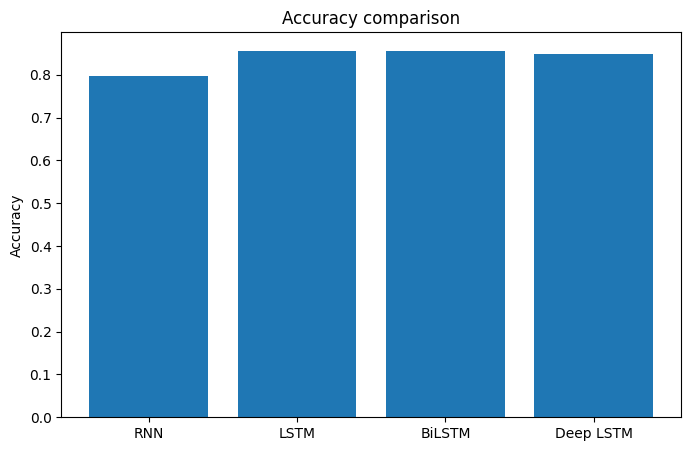

In [26]:
models = [
    "RNN",
    "LSTM",
    "BiLSTM",
    "Deep LSTM"
]
accuracies = [
    acc_rnn,
    acc_lstm,
    acc_bilstm,
    acc_deep
]
plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Accuracy comparison")
plt.ylabel("Accuracy")

plt.show()